<a href="https://colab.research.google.com/github/Karsuman4298/Generative-AI/blob/main/nanoVLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch,math,random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from PIL import Image,ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [22]:
IMG_SIZE=32
EMBED_DIM=64
ATTENTION_HEAD=4
BATCH_SIZE=12
EPOCH=30
LR=3e-4
TEMPERATURE=0.08
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')




In [23]:
# Original learning rate was 3e-4. Let's try a smaller one.
LR = 1e-4

# SYNTHETIC DATASET

In [24]:
color=['red','green','blue','yellow','purple','orange','pink','brown','grey']
shapes=['square','circle','rectangle']
positions=['left','center','right','top','bottom','top-left','top-right','bottom-left','bottom-right']

# DRAWING IMAGE SHAPES

In [25]:

def draw_sample(color, position, shape, img_size=IMG_SIZE):
  img=Image.new('RGB',(img_size,img_size),'white')
  draw=ImageDraw.Draw(img)
  margin=6
  h=w=img_size-2*margin

  # Calculate x coordinates
  if 'left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'top-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'bottom-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'top-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'bottom-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  else: # center or vertical positions
      x0 = margin + w // 4
      x1 = margin + 3 * w // 4

  # Calculate y coordinates
  if 'top' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-left' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-right' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'bottom' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-left' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-right' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  else: # center or horizontal positions
      y0 = margin + h // 4
      y1 = margin + 3 * h // 4

  if shape == 'square':
      draw.rectangle([x0, y0, x1, y1], fill=color, outline='black')
  elif shape == 'circle':
      draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
  else: # triangle
      draw.polygon([(x0 + (x1 - x0) // 2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')
  return img

In [26]:
class ShapeDataset:
    def __init__(self, image_size=64):
        self.image = []
        self.captions = []
        self.image_size = image_size

        for c in color:          # Fixed: changed 'colors' to 'color'
            for p in positions:
                for s in shapes:
                    img_np = draw_sample(c, p, s, img_size=image_size)
                    # Convert to tensor (CHW, normalized to [0,1])
                    img_tensor = (
                        torch.from_numpy(np.asarray(img_np))
                        .permute(2, 0, 1)      # HWC → CHW
                        .float() / 255.0       # ← fixed: / instead of //
                    )
                    self.image.append(img_tensor)
                    self.captions.append(f"{c} {s} {p}")

        # Build vocabulary
        self.vocab, self.word2idx = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({word for text in texts for word in text.split()})
        vocab = ['[CLS]'] + words
        w2i = {w: i for i, w in enumerate(vocab)}
        return vocab, w2i

    def encode_text(self, text):
        toks = [self.word2idx['[CLS]']] + [self.word2idx[word] for word in text.split()]
        return torch.tensor(toks, dtype=torch.long)

    def __len__(self):
        return len(self.image)

    def __getitem__(self, idx):
        return self.image[idx], self.encode_text(self.captions[idx])

In [27]:
full_ds=ShapeDataset()
VOCAB_SIZE=len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)
print(full_ds.captions)


22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'green', 'grey', 'left', 'orange', 'pink', 'purple', 'rectangle', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'yellow']
['red square left', 'red circle left', 'red rectangle left', 'red square center', 'red circle center', 'red rectangle center', 'red square right', 'red circle right', 'red rectangle right', 'red square top', 'red circle top', 'red rectangle top', 'red square bottom', 'red circle bottom', 'red rectangle bottom', 'red square top-left', 'red circle top-left', 'red rectangle top-left', 'red square top-right', 'red circle top-right', 'red rectangle top-right', 'red square bottom-left', 'red circle bottom-left', 'red rectangle bottom-left', 'red square bottom-right', 'red circle bottom-right', 'red rectangle bottom-right', 'green square left', 'green circle left', 'green rectangle left', 'green square center', 'green circle center', 'green rectangle center', 'green squar

# Train - val

In [28]:
train_size=int(0.8 * len(full_ds))
val_size=len(full_ds) - train_size
train_ds,val_ds=torch.utils.data.random_split(full_ds,[train_size,val_size])

In [29]:
train_size,val_size

(194, 49)

In [30]:
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

# Sample datapoint


red red circle top-right


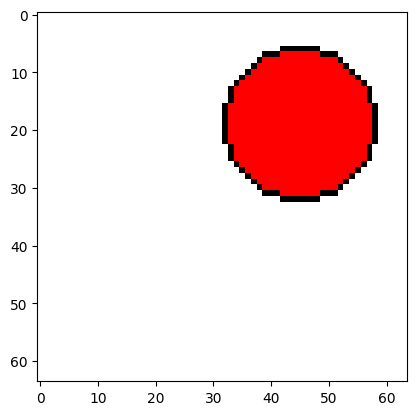

In [31]:
img_batch, caps_batch = next(iter(train_loader))
idx = random.randint(0, len(img_batch) - 1)
plt.imshow(img_batch[idx].permute(1, 2, 0))
print(full_ds.vocab[caps_batch[idx][1]], ' '.join([full_ds.vocab[i.item()] for i in caps_batch[idx][1:]]))

# Image Encoder

In [32]:
class ImageEncoder(nn.Module):
    def __init__(self,EMBED_DIM=EMBED_DIM):
        super().__init__()
        self.convolutions=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,256,kernel_size=3,stride=2,padding=1),
            nn.ReLU()
        )

        self.projection=nn.Linear(256,EMBED_DIM)
        self.layer_norm=nn.LayerNorm(EMBED_DIM)

    def forward(self,x):
      x=self.convolutions(x)
      x=x.mean(dim=[2,3])
      x=self.projection(x)
      x=F.normalize(self.layer_norm(x),dim=-1) # Fixed typo
      return x

# Text Encoder



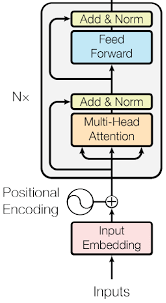

In [33]:
class TextEncoder(nn.Module):
  def __init__(self,embed_dim=EMBED_DIM,num_heads=ATTENTION_HEAD,vocab_size=VOCAB_SIZE,context_window=4):
    super().__init__()
    self.token_embedding=nn.Embedding(vocab_size,embed_dim)
    self.position_embedding=nn.Embedding(context_window,embed_dim)
    self.multihead_attention=nn.MultiheadAttention(embed_dim,num_heads)
    self.projection=nn.Linear(embed_dim,embed_dim)
    self.norm=nn.LayerNorm(embed_dim)



  def forward(self,toks):
    N,L=toks.shape
    position_emb_ids = torch.arange(L,device=toks.device).unsqueeze(0).expand(N,L)
    position_emb_vectors = self.position_embedding(position_emb_ids)
    token_emb_vectors = self.token_embedding(toks)
    x = token_emb_vectors + position_emb_vectors

    # Permute x to (L, N, embed_dim) as expected by MultiheadAttention (batch_first=False by default)
    x = x.permute(1, 0, 2)

    # MultiheadAttention returns (attn_output, attn_output_weights)
    x, _ = self.multihead_attention(x,x,x)

    # Permute x back to (N, L, embed_dim)
    x = x.permute(1, 0, 2)

    x=x[:,0] # Take the [CLS] token embedding
    x=self.projection(x)
    x=F.normalize(self.norm(x),dim=-1)
    return x

#CLIP Loss

In [34]:

def clip_loss(img_emb,txt_emb,temperature=TEMPERATURE):

  logits= img_emb @ txt_emb.T/temperature
  targets=torch.arange(img_emb.size(0),device=img_emb.device)
  loss_i=F.cross_entropy(logits,targets)
  loss_t=F.cross_entropy(logits.T,targets)
  return ((loss_i + loss_t)/2.0)


#Model , data, optimizer

In [35]:
img_enc=ImageEncoder().to(device)
txt_enc=TextEncoder().to(device)
params=list(img_enc.parameters())+list(txt_enc.parameters())
optimizer=torch.optim.Adam(params,lr=LR)

In [36]:
def show_img(t,titile=None):
  img=(t.permute(1,2,0).numpy()*255).astype(np.uint8)
  plt.figure(figsize=(2.2,2.2))
  plt.axis('off')
  if titile:
    plt.title(titile)
  plt.imshow(img)
  plt.show()


Sample image and caption for embedding vizualization:'red rectangle left' 


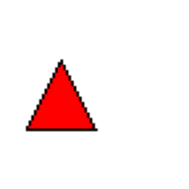

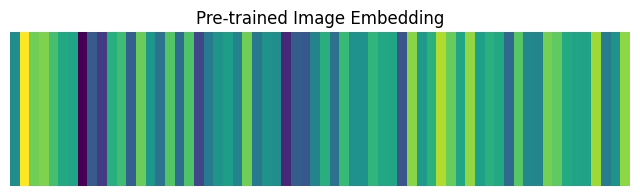

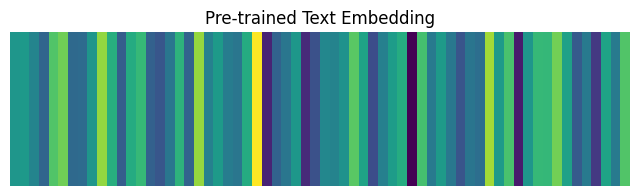

In [37]:
img_enc=ImageEncoder().to(device)
txt_enc=TextEncoder().to(device)

img_enc.eval(); txt_enc.eval()

with torch.no_grad():
  #select random indexes
  random_idx=random.randrange(len(full_ds))
  sample_img,sample_tok=full_ds[random_idx]
  sample_cap = full_ds.captions[random_idx]
  sample_img=sample_img.unsqueeze(0).to(device)
  sample_tok=sample_tok.unsqueeze(0).to(device)
  pre_train_img_emb=img_enc(sample_img).squeeze(0).cpu().numpy()
  pre_train_txt_emb=txt_enc(sample_tok).squeeze(0).cpu().numpy()


  print(f"Sample image and caption for embedding vizualization:'{sample_cap}' ")
  show_img(sample_img.squeeze(0).cpu())



  def plot_embedding(embedding,title):
    plt.figure(figsize=(8,2))
    plt.imshow(embedding.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_embedding(pre_train_img_emb,'Pre-trained Image Embedding')
plot_embedding(pre_train_txt_emb,'Pre-trained Text Embedding')


# Training Loop

In [38]:
best_val= float('inf')
for epoch in range(1,EPOCH+1):
  img_enc.train(); txt_enc.train()
  total=0.0

  for img,toks in train_loader:
    img=img.to(device)
    toks=toks.to(device)
    optimizer.zero_grad(set_to_none=True)
    ie=img_enc(img)
    te=txt_enc(toks)
    loss=clip_loss(ie,te)
    loss.backward()
    optimizer.step()
    total+=loss.item()*img.size(0)
  train_loss=total/(len(train_loader)*BATCH_SIZE)



  img_enc.eval(); txt_enc.eval()
  with torch.no_grad():
    vtotal,n=0.0,0
    for imgs,toks in val_loader:
      imgs=imgs.to(device)
      toks=toks.to(device)
      vtotal += clip_loss(img_enc(imgs),txt_enc(toks)).item()*imgs.size(0)
      n += imgs.size(0)
    val_loss=vtotal/n


  print(f"Epoch {epoch:02d} | Train {train_loss:.4f} | val {val_loss:.4f}")
  best_val=min(best_val,val_loss)


Epoch 01 | Train 2.4045 | val 2.4874
Epoch 02 | Train 2.4067 | val 2.4874
Epoch 03 | Train 2.4084 | val 2.4874
Epoch 04 | Train 2.4056 | val 2.4874
Epoch 05 | Train 2.4065 | val 2.4874
Epoch 06 | Train 2.4077 | val 2.4874
Epoch 07 | Train 2.4074 | val 2.4874
Epoch 08 | Train 2.4066 | val 2.4874
Epoch 09 | Train 2.4073 | val 2.4874
Epoch 10 | Train 2.4078 | val 2.4874
Epoch 11 | Train 2.4060 | val 2.4874
Epoch 12 | Train 2.4078 | val 2.4874
Epoch 13 | Train 2.4038 | val 2.4874
Epoch 14 | Train 2.4064 | val 2.4874
Epoch 15 | Train 2.4059 | val 2.4874
Epoch 16 | Train 2.4037 | val 2.4874
Epoch 17 | Train 2.4057 | val 2.4874
Epoch 18 | Train 2.4073 | val 2.4874
Epoch 19 | Train 2.4059 | val 2.4874
Epoch 20 | Train 2.4074 | val 2.4874
Epoch 21 | Train 2.4063 | val 2.4874
Epoch 22 | Train 2.4070 | val 2.4874
Epoch 23 | Train 2.4079 | val 2.4874
Epoch 24 | Train 2.4046 | val 2.4874
Epoch 25 | Train 2.4065 | val 2.4874
Epoch 26 | Train 2.4046 | val 2.4874
Epoch 27 | Train 2.4087 | val 2.4874
E

It appears the training loss is stagnant, indicating the model is not learning. A possible reason is that the learning rate is too high. Let's try lowering the learning rate.